# 🚀 Treinamento do AcneNet com Todos os Dados (Train + Val) e Avaliação no Teste

In [1]:
# 📦 Imports
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
# ⚙️ Configurações
IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 30
DATA_DIR = r"C:/Users/GonLu/Documents/Projetos/pibic_final/data/processed/forehead"
import torch
print(torch.__version__)  # Deve mostrar 2.3.1+cu121
print(torch.cuda.is_available())  # True
print(torch.cuda.get_device_name(0))
  



2.2.1+cu121
True
NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
# 📂 Datasets
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=transform)
val_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), transform=transform)
train_ds = ConcatDataset([train_ds, val_ds])
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [4]:
# 🧠 Modelo AcneNet
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, downsample=False):
        super().__init__()
        stride = 2 if downsample else 1
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = None
        if downsample or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class AcneNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(64, 3)
        self.layer2 = self._make_layer(128, 4, downsample=True)
        self.layer3 = self._make_layer(256, 6, downsample=True)
        self.layer4 = self._make_layer(512, 3, downsample=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, blocks, downsample=False):
        layers = [ResidualBlock(self.in_channels, out_channels, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

In [7]:
# ⚙️ Inicialização do modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AcneNet(num_classes=4).to(device)

# ✅ Aqui entra o class_weights
import torch

class_weights = torch.tensor([1.0, 1.0, 1.2, 1.5], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)



In [8]:
# 🔁 Treinamento
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        pbar.set_postfix({'Loss': running_loss / (total / BATCH_SIZE), 'Acc': 100. * correct / total})

Epoch 30/30: 100%|██████████| 351/351 [00:28<00:00, 12.21it/s, Loss=0.193, Acc=92]  


In [13]:
# 💾 Salvar modelo final
torch.save(model.state_dict(), "acnenet_forehead_final.pth")
print("✅ Modelo salvo como acnenet_forehead_final.pth")

✅ Modelo salvo como acnenet_forehead_final.pth


🎯 Test Accuracy: 55.24%


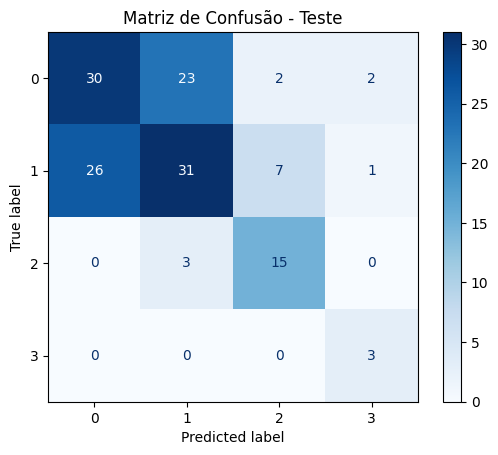

              precision    recall  f1-score   support

           0       0.54      0.53      0.53        57
           1       0.54      0.48      0.51        65
           2       0.62      0.83      0.71        18
           3       0.50      1.00      0.67         3

    accuracy                           0.55       143
   macro avg       0.55      0.71      0.61       143
weighted avg       0.55      0.55      0.55       143



In [14]:
# 📊 Avaliação no test
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
test_correct = 0
test_total = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100. * test_correct / test_total
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '1', '2', '3'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão - Teste")
plt.show()

print(classification_report(all_labels, all_preds, target_names=['0', '1', '2', '3']))